In [ ]:
"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""
import numpy as np


A = np.array(
    [
        [1, 1, 1, 1, 1],
        [1, 0, 0, 0, 1],
        [1, 0, 0, 0, 1],
        [1, 0, 0, 0, 1],
        [1, 1, 1, 1, 1],
    ]
)

print(A)


np.random.seed(42)
random_data = np.random.randn(100, 3)

normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print(normalized)


X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

X_transpose = X.T
X_T_X_inverse = np.linalg.inv(X_transpose @ X)

theta_hat = X_T_X_inverse @ X_transpose @ y

print("--- Task 3: Linear Regression via Normal Equation ---")
print(f"True Theta:      {true_theta}")
print(f"Estimated Theta: {theta_hat}")
print(f"Difference:      {np.abs(true_theta - theta_hat)}")

[[1 1 1 1 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 1 1 1 1]]
[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e-01 -5.06767212e-01  4.84818398e-01]
 [ 1.14447901e+0

In [ ]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    "student_id": range(1000, 1000 + n_students),
    "major": np.random.choice(["CS", "Math", "Physics", "Biology"], n_students),
    "year": np.random.choice([1, 2, 3, 4], n_students),
    "exam_score": np.random.normal(75, 10, n_students).clip(0, 100),
    "assignments_completed": np.random.randint(0, 11, n_students),
    "hours_studied": np.random.normal(15, 5, n_students).clip(1, 40),
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), "exam_score"] = np.nan
df.loc[np.random.choice(n_students, 5), "hours_studied"] = np.nan

# Task 1
print(df.describe())  # Describes the dataset

df.isnull().sum()  # Counts the missing values

df["exam_score"] = df["exam_score"].fillna(
    df.groupby("major")["exam_score"].transform("mean")
)
df["hours_studied"] = df["hours_studied"].fillna(
    df.groupby("year")["hours_studied"].transform("median")
)

df_filled = df.copy()
print(df_filled)  # Flls the empty dataset with the mean value

print(df_filled)  # Flls the empty dataset with the median value


# Task 2
# Group and calculate the mean
average_score_by_major = df.groupby("major")["exam_score"].agg(["mean"])
print("Average exam score by major:\n", average_score_by_major)

# Sort by the 'mean' column and grab the index label of the very top row
best_major = average_score_by_major.sort_values(by="mean", ascending=False).index[0]
print(f"Major with the highest average score: {best_major}")

#
# 1. Initialize the column with a default value for everyone (<70 bucket)
df["performance"] = "Needs Improvement"

# 2. Update the 'Average' bucket (70 to 80)
df.loc[(df["exam_score"] >= 70) & (df["exam_score"] < 80), "performance"] = "Average"

# 3. Update the 'Good' bucket (80 to 90)
df.loc[(df["exam_score"] >= 80) & (df["exam_score"] <= 90), "performance"] = "Good"

# 4. Update the 'Excellent' bucket (>90)
df.loc[df["exam_score"] > 90, "performance"] = "Excellent"

print(df[["exam_score", "performance"]].head())

        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2.000000   
50%    1099.500000    3.000000   75.728033               4.000000   
75%    1149.250000    4.000000   81.813642               8.000000   
max    1199.000000    4.000000  100.000000              10.000000   

       hours_studied  
count     195.000000  
mean       14.776761  
std         5.251905  
min         1.295226  
25%        11.637963  
50%        14.575456  
75%        18.345691  
max        28.918887  
     student_id    major  year  exam_score  assignments_completed  \
0          1000  Physics     3   68.199753                     10   
1          1001  Biology     4   

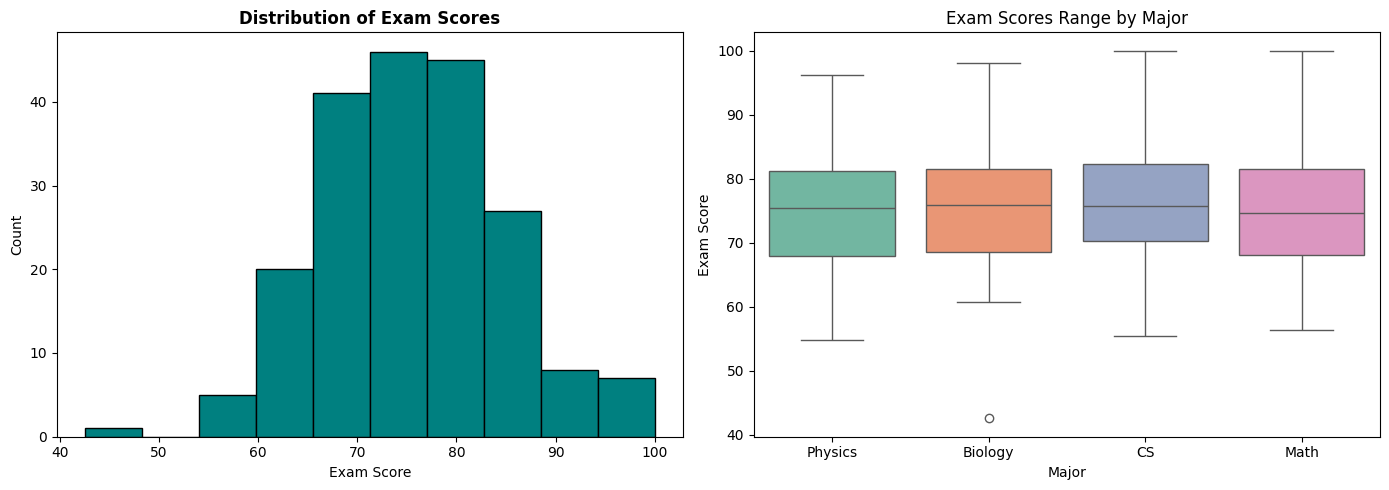

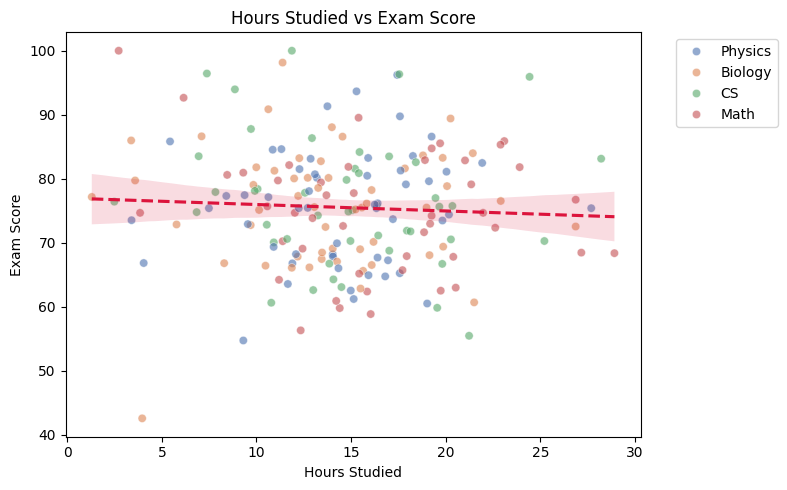

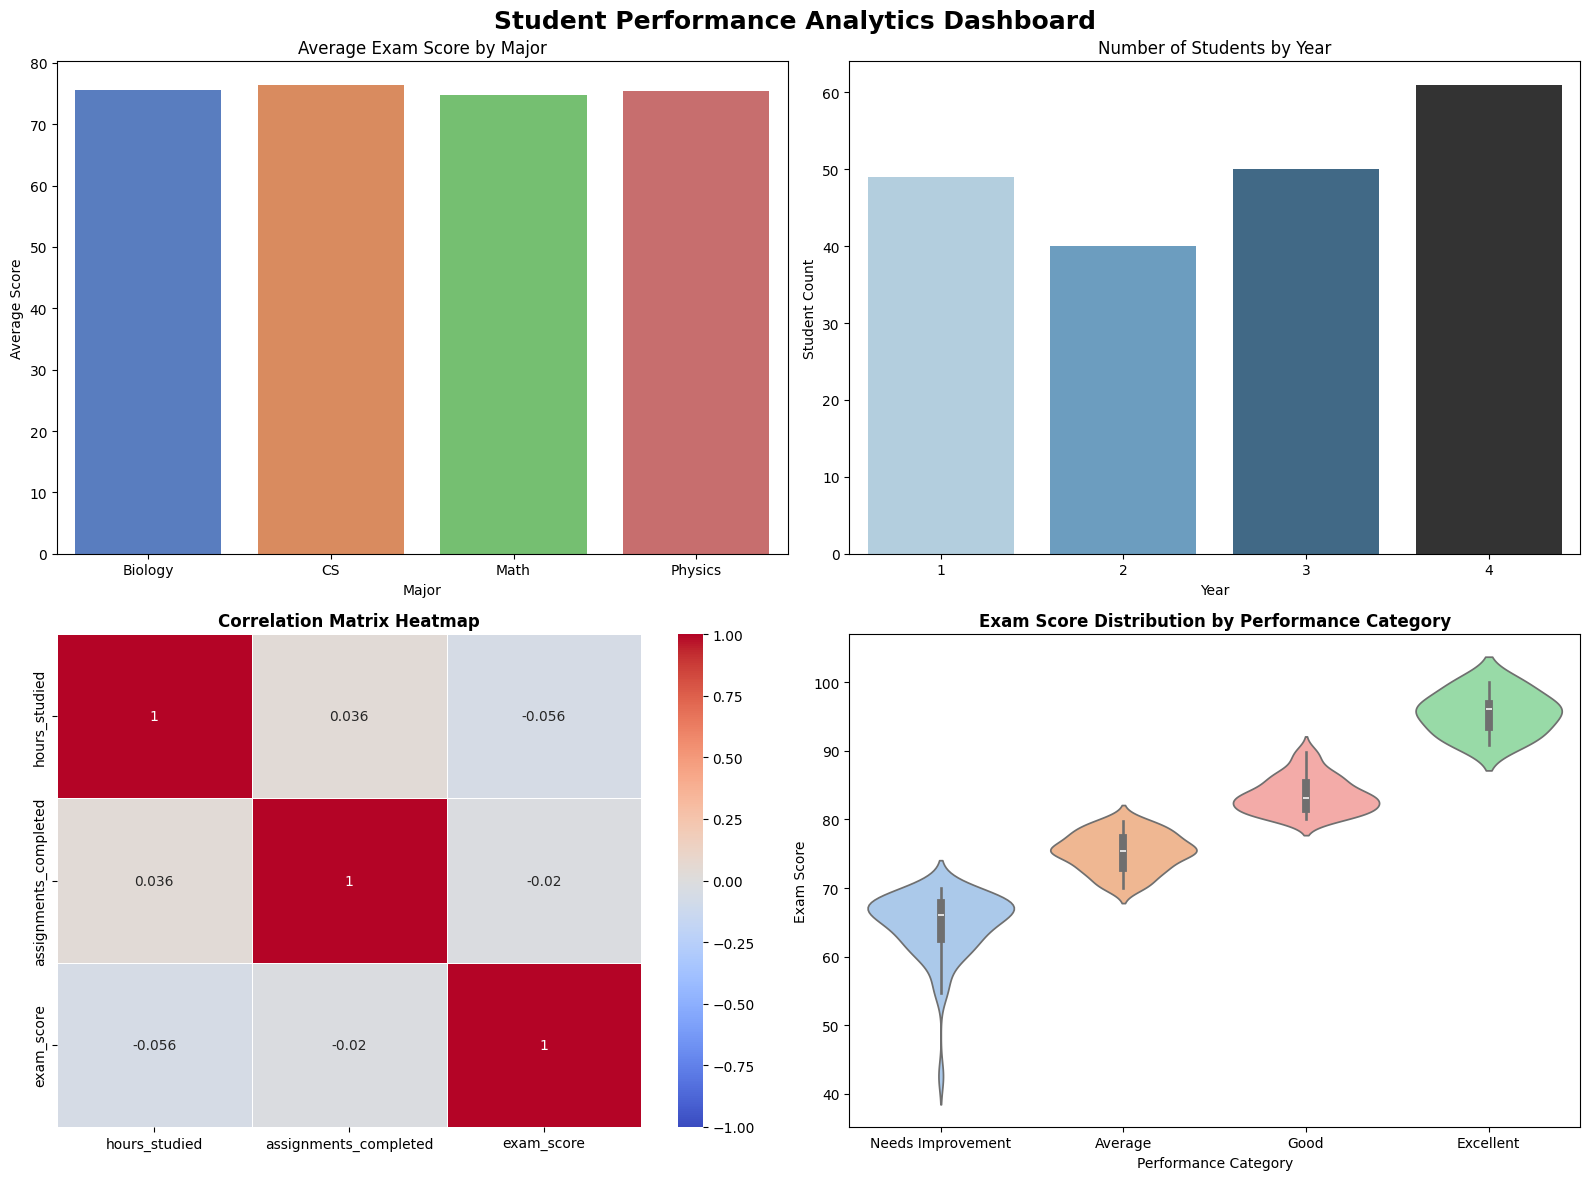

In [ ]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["exam_score"], bins=10, edgecolor="black", color="teal")
axes[0].set_title("Distribution of Exam Scores", fontsize=12, weight="bold")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Count")

sns.boxplot(
    ax=axes[1],
    data=df,
    x="major",
    y="exam_score",
    hue="major",
    palette="Set2",
    legend=False,
)
axes[1].set_title("Exam Scores Range by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x="hours_studied", y="exam_score", hue="major", palette="deep", alpha=0.6
)
sns.regplot(
    data=df,
    x="hours_studied",
    y="exam_score",
    scatter=False,
    line_kws={"color": "crimson", "linestyle": "--"},
)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

fig3, axes = plt.subplots(2, 2, figsize=(16, 12))

avg_scores = df.groupby("major")["exam_score"].mean().reset_index()
sns.barplot(
    ax=axes[0, 0],
    data=avg_scores,
    x="major",
    y="exam_score",
    hue="major",
    palette="muted",
    legend=False,
)
axes[0, 0].set_title("Average Exam Score by Major")
axes[0, 0].set_xlabel("Major")
axes[0, 0].set_ylabel("Average Score")

# 2. Count plot: Number of students by year
sns.countplot(
    ax=axes[0, 1], data=df, x="year", hue="year", palette="Blues_d", legend=False
)
axes[0, 1].set_title("Number of Students by Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Student Count")

numeric_cols = df[["hours_studied", "assignments_completed", "exam_score"]]
correlation_matrix = numeric_cols.corr()

sns.heatmap(
    ax=axes[1, 0],
    data=correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
axes[1, 0].set_title("Correlation Matrix Heatmap", fontsize=12, weight="bold")


# ---------------------------------------------------------------------
# Panel 4: Violin plot - Exam score distribution by performance category
# ---------------------------------------------------------------------
sns.violinplot(
    ax=axes[1, 1],
    data=df,
    x="performance",
    y="exam_score",
    order=[
        "Needs Improvement",
        "Average",
        "Good",
        "Excellent",
    ],  # Keeps categories ordered
    hue="performance",
    palette="pastel",
    legend=False,
)
axes[1, 1].set_title(
    "Exam Score Distribution by Performance Category", fontsize=12, weight="bold"
)
axes[1, 1].set_xlabel("Performance Category")
axes[1, 1].set_ylabel("Exam Score")


# ---------------------------------------------------------------------
# Global Dashboard Adjustments
# ---------------------------------------------------------------------
# Add an overarching main title for the dashboard canvas
plt.suptitle(
    "Student Performance Analytics Dashboard", fontsize=18, weight="bold", y=0.98
)

# Clean up layout text spacing so labels don't clip or overlap
plt.tight_layout()
plt.show()

--- Age Group Metrics ---
           Number of Customers  Average CLV     Total CLV  Average Income
age_group                                                                
18-25                       81   241.153717  19533.451053    50634.018330
26-35                       73   235.777466  17211.755008    48747.148046
36-50                      160   245.019561  39203.129763    48516.895668
51-70                      186   263.166335  48948.938378    50713.163384


Top 10% Cutoff Value: 565.241752835561
     age        income  purchase_frequency  avg_purchase_value  churn_risk  \
303   52  41762.460678                  12          124.223342    0.000000   
456   32  15000.000000                  11          115.676858    0.083333   
200   23  30285.479073                  10          119.720949    0.166667   
82    65  69502.394668                  10          117.589989    0.166667   
468   49  56156.035378                  11           96.779356    0.083333   
6     38  58876.38856

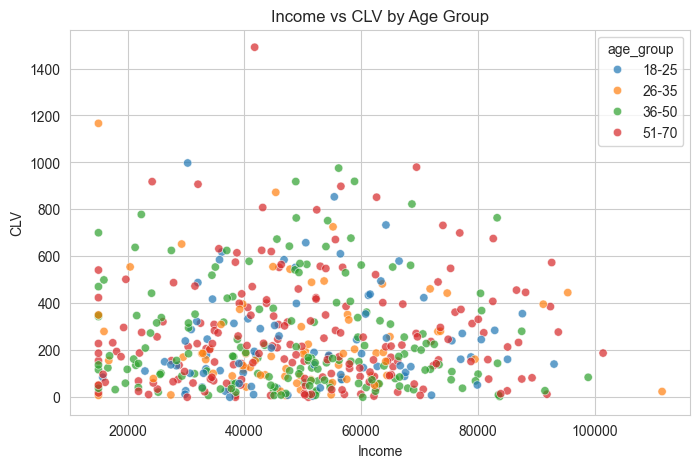

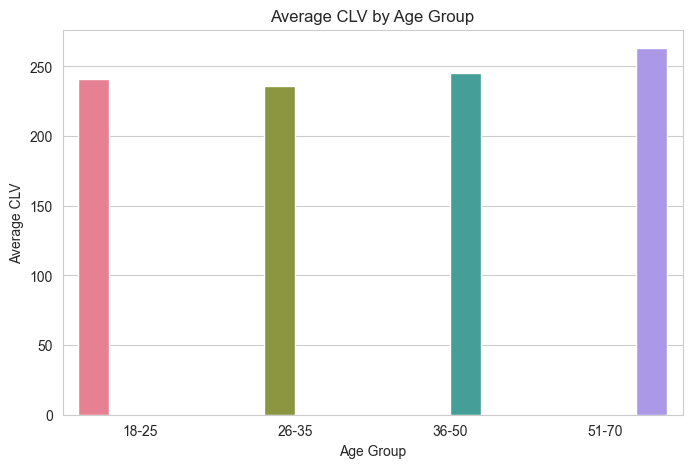

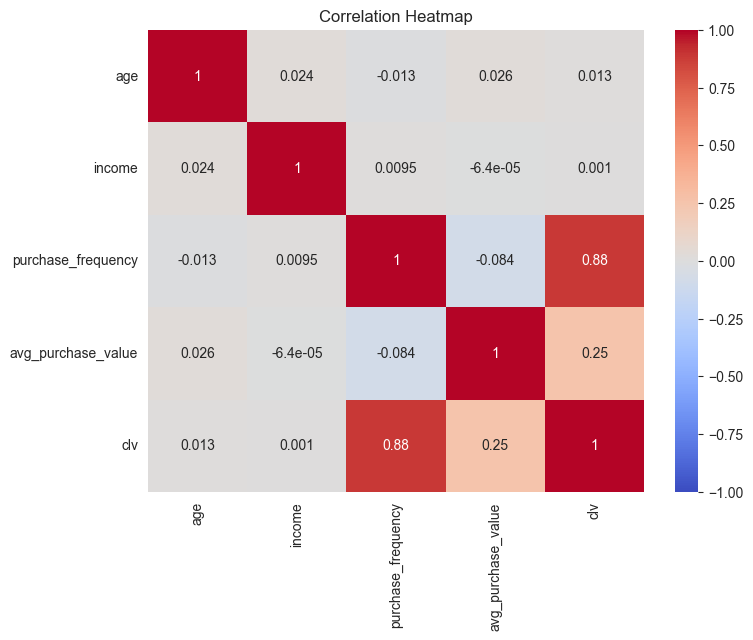

In [ ]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame(
    {
        "age": ages,
        "income": income,
        "purchase_frequency": purchase_freq,
        "avg_purchase_value": avg_purchase_value,
    }
)

max_frequency = customers["purchase_frequency"].max()
customers["churn_risk"] = 1 - (customers["purchase_frequency"] / max_frequency)

customers["clv"] = (
    customers["purchase_frequency"]
    * customers["avg_purchase_value"]
    * (1 - customers["churn_risk"])
)


age_bins = [17, 25, 35, 50, 70]
age_labels = ["18-25", "26-35", "36-50", "51-70"]
customers["age_group"] = pd.cut(customers["age"], bins=age_bins, labels=age_labels)
# Grouping and aggregation matching the textbook style
age_group_analysis = customers.groupby("age_group", observed=False)["clv"].agg(
    ["count", "mean", "sum"]
)
# Renaming columns for clarity
age_group_analysis.columns = ["Number of Customers", "Average CLV", "Total CLV"]

# Adding Average Income separately to match required metrics
age_group_analysis["Average Income"] = customers.groupby("age_group", observed=False)[
    "income"
].mean()

print("--- Age Group Metrics ---")
print(age_group_analysis)
print("\n" + "=" * 50 + "\n")

# -------------------------------------------------------------------------
# 4. Identify Top 10% of Customers by CLV
# -------------------------------------------------------------------------
# Finding the threshold value using quantile
clv_cutoff = customers["clv"].quantile(0.90)
top_customers = customers[customers["clv"] >= clv_cutoff]
top_customers = top_customers.sort_values("clv", ascending=False)

print(f"Top 10% Cutoff Value: {clv_cutoff}")
print(top_customers.head(10))
print("\n" + "=" * 50 + "\n")

# -------------------------------------------------------------------------
# 5. Create Visualizations
# -------------------------------------------------------------------------
# Set Seaborn style matching your notes style
sns.set_style("whitegrid")

# Plot 1: Scatter plot of income vs CLV (color by age group)
fig1, ax1 = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=customers, x="income", y="clv", hue="age_group", alpha=0.7)
ax1.set_xlabel("Income")
ax1.set_ylabel("CLV")
ax1.set_title("Income vs CLV by Age Group")
plt.show()

# Plot 2: Bar chart of average CLV by age group
fig2, ax2 = plt.subplots(figsize=(8, 5))
# Reset index to allow categorical plotting via seaborn
plot_data = age_group_analysis.reset_index()
# Added hue mapping here to safely use palette choices without warnings
sns.barplot(
    data=plot_data,
    x="age_group",
    y="Average CLV",
    hue="age_group",
    palette="husl",
    legend=False,
)
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Average CLV")
ax2.set_title("Average CLV by Age Group")
plt.show()

# Plot 3: Correlation heatmap
fig3, ax3 = plt.subplots(figsize=(8, 6))
# Filter down to numeric columns for correlation matrix calculation
numeric_cols = customers[
    ["age", "income", "purchase_frequency", "avg_purchase_value", "clv"]
]
correlation = numeric_cols.corr()
# Standardized scale bounds with vmin and vmax parameters
sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
ax3.set_title("Correlation Heatmap")
plt.show()